In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
from pathlib import Path

import zuko
import torch
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load the dataset

In [2]:
data_dir = Path('datasets')
X = pd.read_csv(filepath_or_buffer=data_dir / 'natural_disaster_county.csv', )
X.drop(columns=['Unnamed: 0'], inplace=True)

In [3]:
X.head()

,STATE,CZ_TYPE,BEGIN_DATE_TIME,END_DATE_TIME,DAMAGES,CASUALTIES,FIPS,EVENT_TYPE_0,EVENT_TYPE_1,EVENT_TYPE_2,...,BEGIN_HOUR_cos,BEGIN_DOY_sin,BEGIN_DOY_cos,END_HOUR_sin,END_HOUR_cos,END_DOY_sin,END_DOY_cos,TOT_POP,land_sq_mi,water_sq_mi
0,SOUTH CAROLINA,C,2016-07-15 17:15:00,2016-07-15 17:15:00,2000.0,0,45091,0.0,0.0,0.0,...,-0.258819,-0.238033,-0.971257,-0.965926,-2.588190e-01,-0.238033,-0.971257,283862.0,682.45,13.27
1,NEW YORK,C,2016-08-02 03:00:00,2016-08-02 06:22:00,0.0,0,36093,1.0,0.0,0.0,...,0.707107,-0.522133,-0.852864,1.000000,6.123234e-17,-0.522133,-0.852864,159294.0,206.10,3.52
2,NEW YORK,C,2016-08-02 03:15:00,2016-08-02 06:22:00,0.0,0,36001,1.0,0.0,0.0,...,0.707107,-0.522133,-0.852864,1.000000,6.123234e-17,-0.522133,-0.852864,314024.0,523.45,9.76
3,NEW YORK,C,2016-08-02 03:00:00,2016-08-02 06:22:00,0.0,0,36001,1.0,0.0,0.0,...,0.707107,-0.522133,-0.852864,1.000000,6.123234e-17,-0.522133,-0.852864,314024.0,523.45,9.76
4,NEW YORK,C,2016-08-02 03:15:00,2016-08-02 06:22:00,0.0,0,36093,1.0,0.0,0.0,...,0.707107,-0.522133,-0.852864,1.000000,6.123234e-17,-0.522133,-0.852864,159294.0,206.10,3.52


In [4]:
display(X.columns)
display(X.shape)
display(X.describe())

Index(['STATE', 'CZ_TYPE', 'BEGIN_DATE_TIME', 'END_DATE_TIME', 'DAMAGES',
       'CASUALTIES', 'FIPS', 'EVENT_TYPE_0', 'EVENT_TYPE_1', 'EVENT_TYPE_2',
       'EVENT_TYPE_3', 'EVENT_TYPE_4', 'EVENT_TYPE_5', 'EVENT_TYPE_6',
       'EVENT_TYPE_7', 'EVENT_TYPE_8', 'BEGIN_HOUR_sin', 'BEGIN_HOUR_cos',
       'BEGIN_DOY_sin', 'BEGIN_DOY_cos', 'END_HOUR_sin', 'END_HOUR_cos',
       'END_DOY_sin', 'END_DOY_cos', 'TOT_POP', 'land_sq_mi', 'water_sq_mi'],
      dtype='object')

(126307, 27)

,DAMAGES,CASUALTIES,FIPS,EVENT_TYPE_0,EVENT_TYPE_1,EVENT_TYPE_2,EVENT_TYPE_3,EVENT_TYPE_4,EVENT_TYPE_5,EVENT_TYPE_6,...,BEGIN_HOUR_cos,BEGIN_DOY_sin,BEGIN_DOY_cos,END_HOUR_sin,END_HOUR_cos,END_DOY_sin,END_DOY_cos,TOT_POP,land_sq_mi,water_sq_mi
count,1.263070e+05,126307.000000,126307.000000,126307.000000,126307.0,126307.000000,126307.000000,126307.000000,126307.000000,126307.000000,...,126307.000000,126307.000000,126307.000000,1.263070e+05,126307.000000,126307.000000,126307.000000,1.263070e+05,126307.000000,126307.000000
mean,6.775625e+05,0.039729,30237.297561,0.368499,0.0,0.456261,0.000032,0.082181,0.000040,0.092988,...,-0.149025,0.149338,-0.435624,-3.759215e-01,-0.112895,0.147554,-0.438288,2.282988e+05,1242.875216,52.163939
std,5.279111e+07,1.427472,15061.120413,0.482400,0.0,0.498085,0.005627,0.274641,0.006292,0.290416,...,0.628971,0.678379,0.572484,6.609895e-01,0.639560,0.678408,0.570876,5.704496e+05,1950.812282,176.811425
min,0.000000e+00,0.000000,1001.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.000000,-0.999963,-1.000000,-1.000000e+00,-1.000000,-0.999963,-1.000000,6.700000e+01,0.000000,0.000000
25%,0.000000e+00,0.000000,19137.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.707107,-0.492548,-0.902030,-9.659258e-01,-0.707107,-0.492548,-0.902030,1.411300e+04,517.390000,2.240000
50%,0.000000e+00,0.000000,29189.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.258819,0.271234,-0.653680,-7.071068e-01,-0.258819,0.271234,-0.666575,4.214800e+04,719.950000,7.670000
75%,0.000000e+00,0.000000,45063.000000,1.000000,0.0,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.258819,0.789418,-0.111355,1.224647e-16,0.500000,0.789418,-0.111355,1.683520e+05,1055.800000,22.930000
max,1.000010e+10,234.000000,56045.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.999963,1.000000,1.000000e+00,1.000000,0.999963,1.000000,9.996634e+06,88817.120000,5945.530000


It's important to scale the data because Normalizing Flows try to learn an invertible function $f$ which map our complex (context) data $X$ in a "standard" distribution. If we pass skewed data in strange distribution our model struggle first to transpose this data into a standard distribution, and only then it can try to learn how to model this distribution. 

It's important to use different scaler for the target and the context because with the function scaler.inverse_transform() (of the scaler from sklearn StandardScaler) we can take our standardized data back to their original distribution.
During training our model will reason only in term of standardized data, but when we inference a new natural disaster we want to know the amount of damage not in term of a standard value but with a real value, and saving the mean and the standard deviation before pass our data to the model we can do that.

In [5]:
# Standardize surfaces and population with one scaler
context_scaler = StandardScaler()
X[['TOT_POP', 'land_sq_mi', 'water_sq_mi']] = context_scaler.fit_transform(X[['TOT_POP', 'land_sq_mi', 'water_sq_mi']])

In [6]:
# Standardize damages with log transform (to deal with heavy tail distribution) and with another scaler
X[['DAMAGES']] = np.log1p(X[['DAMAGES']])

target_scaler = StandardScaler()
X[['DAMAGES']] = target_scaler.fit_transform(X[['DAMAGES']])

In [7]:
X.describe()

,DAMAGES,CASUALTIES,FIPS,EVENT_TYPE_0,EVENT_TYPE_1,EVENT_TYPE_2,EVENT_TYPE_3,EVENT_TYPE_4,EVENT_TYPE_5,EVENT_TYPE_6,...,BEGIN_HOUR_cos,BEGIN_DOY_sin,BEGIN_DOY_cos,END_HOUR_sin,END_HOUR_cos,END_DOY_sin,END_DOY_cos,TOT_POP,land_sq_mi,water_sq_mi
count,1.263070e+05,126307.000000,126307.000000,126307.000000,126307.0,126307.000000,126307.000000,126307.000000,126307.000000,126307.000000,...,126307.000000,126307.000000,126307.000000,1.263070e+05,126307.000000,126307.000000,126307.000000,1.263070e+05,1.263070e+05,1.263070e+05
mean,-5.265488e-17,0.039729,30237.297561,0.368499,0.0,0.456261,0.000032,0.082181,0.000040,0.092988,...,-0.149025,0.149338,-0.435624,-3.759215e-01,-0.112895,0.147554,-0.438288,-5.400501e-18,1.800167e-17,4.770442e-17
std,1.000004e+00,1.427472,15061.120413,0.482400,0.0,0.498085,0.005627,0.274641,0.006292,0.290416,...,0.628971,0.678379,0.572484,6.609895e-01,0.639560,0.678408,0.570876,1.000004e+00,1.000004e+00,1.000004e+00
min,-4.414556e-01,0.000000,1001.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,-1.000000,-0.999963,-1.000000,-1.000000e+00,-1.000000,-0.999963,-1.000000,-4.000927e-01,-6.371090e-01,-2.950270e-01
25%,-4.414556e-01,0.000000,19137.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.707107,-0.492548,-0.902030,-9.659258e-01,-0.707107,-0.492548,-0.902030,-3.754700e-01,-3.718903e-01,-2.823581e-01
50%,-4.414556e-01,0.000000,29189.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.258819,0.271234,-0.653680,-7.071068e-01,-0.258819,0.271234,-0.666575,-3.263243e-01,-2.680562e-01,-2.516473e-01
75%,-4.414556e-01,0.000000,45063.000000,1.000000,0.0,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.258819,0.789418,-0.111355,1.224647e-16,0.500000,0.789418,-0.111355,-1.050874e-01,-9.589644e-02,-1.653403e-01
max,5.431859e+00,234.000000,56045.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,0.999963,1.000000,1.000000e+00,1.000000,0.999963,1.000000,1.712399e+01,4.489135e+01,3.333150e+01


# NSF

### Prepare training and test sets

In [8]:
y = X['DAMAGES'].copy().values # numpy
X = X.drop(columns=['STATE', 'CZ_TYPE', 'BEGIN_DATE_TIME', 'END_DATE_TIME', 'DAMAGES', 'CASUALTIES', 'FIPS']).values #numpy
print(X.shape, y.shape)

(126307, 20) (126307,)


In [9]:
# Split into train, validation and test sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [10]:
# DataLoaders
def to_loader(X, y, batch_size=128, shuffle=False):
    dataset = TensorDataset(
        torch.FloatTensor(X),
        torch.FloatTensor(y).reshape(-1, 1)  # handle both (N,) and (N,1)
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)

### Create the model

In [11]:
# Configuration parameters
n_context_features = X_train.shape[1] # what we pass to the model as conditions
n_sample_feature = 1    # what we want to predict (the damage)

In [12]:
flow = zuko.flows.NSF(
    features=n_sample_feature,
    context=n_context_features,
    transforms=8,   # number of transformation layers
    hidden_features=[256, 256],    # hidden layer sizes in the NN
    bins=16 # more bins to handle complex distribution
)

print(f"NSF model created with {sum(p.numel() for p in flow.parameters())} parameters")

NSF model created with 665976 parameters


### Training

In [13]:
# Training parameters
n_epochs = 300
lr=5e-4
batch_size=256

In [14]:
# Prepare the data
train_loader = to_loader(X_train, y_train, batch_size=batch_size, shuffle=True)
val_loader = to_loader(X_val, y_val, batch_size=batch_size)
test_loader = to_loader(X_test, y_test, batch_size=batch_size)

In [15]:
# Setup optimizer
optimizer = torch.optim.AdamW(flow.parameters(), lr=lr, weight_decay=1e-4)

In [16]:
# Setup scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=15)

In [17]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

La loss (Negative Log Likelihood) può essere negativa (perché è log-densità, non probabilità semplice). L'importante è che diminuisca nel tempo (diventi "più negativa" o scenda verso valori più bassi).

In [18]:
# Training loop
train_losses = []
std_train_losses = []
val_losses = []
std_val_losses = []
learning_rates = []
best_val_loss = float('inf')
patience_counter = 0
max_patience = 30

flow = flow.to(device)
print(f"Training on {device}")

for epoch in range(n_epochs):

    # Training
    flow.train()
    epoch_train_losses = []

    for context_batch, damage_batch in train_loader:
        context_batch = context_batch.to(device)
        damage_batch = damage_batch.to(device)

        # Forward pass
        loss = -flow(context_batch).log_prob(damage_batch).mean()

        # Backward pass
        optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(flow.parameters(), max_norm=1.0) # for better stability

        optimizer.step()

        epoch_train_losses.append(loss.item())

    train_losses.append(np.mean(epoch_train_losses))
    std_train_losses.append(np.std(epoch_train_losses))

    # Validation
    flow.eval()
    epoch_val_losses = []

    with torch.no_grad():
        for context_batch, damage_batch in val_loader:
            context_batch = context_batch.to(device)
            damage_batch = damage_batch.to(device)

            val_loss = -flow(context_batch).log_prob(damage_batch).mean()

            epoch_val_losses.append(val_loss.item())

        val_losses.append(np.mean(epoch_val_losses))
        std_val_losses.append(np.std(epoch_val_losses))

    # LR scheduler
    scheduler.step(val_losses[-1])
    learning_rates.append(optimizer.param_groups[0]['lr'])

    # Early stopping & model checkpoint
    if val_losses[-1] < best_val_loss:
        best_val_loss = val_losses[-1]
        patience_counter = 0

        # Save all the model and training information to load the model weights or continue the training
        torch.save({
            'epoch': epoch,                           # ← Numero epoca (int)
            'model_state_dict': flow.state_dict(),    # ← PESI del modello
            'optimizer_state_dict': optimizer.state_dict(),  # ← Stato optimizer (momentum, ecc.)
            'scheduler_state_dict': scheduler.state_dict(),  # ← Stato scheduler
            'train_loss': train_losses[-1],             # ← Metrica (float)
            'val_loss': val_losses[-1],                 # ← Metrica (float)
        }, 'best_nsf_model.pth')

    else:
        patience_counter += 1


    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch\t[{epoch+1}/{n_epochs}] | "
              f"Train Loss: {train_losses[-1]:.4f} ± {std_train_losses[-1]:.4f} | "
              f"Val Loss: {val_losses[-1]:.4f} ± {std_val_losses[-1]:.4f} | "
              f"Current LR: {learning_rates[-1]:.2e} | "
              f"Patience: {patience_counter}/{max_patience}")
        
    if patience_counter >= max_patience:
        print(f"Early stopping at epoch: {epoch+1}")
        print(f"Best val loss: {best_val_loss}")
        break


Training on cuda
Epoch	[1/300] | Train Loss: -1.3830 ± 0.7150 | Val Loss: -0.3469 ± 0.0859 | Current LR: 5.00e-04 | Patience: 0/30
Epoch	[5/300] | Train Loss: -2.7659 ± 0.8992 | Val Loss: -3.7264 ± 0.2250 | Current LR: 5.00e-04 | Patience: 0/30
Epoch	[10/300] | Train Loss: -2.9028 ± 1.0314 | Val Loss: -3.7574 ± 0.3245 | Current LR: 5.00e-04 | Patience: 0/30
Epoch	[15/300] | Train Loss: -2.9712 ± 1.0259 | Val Loss: -3.2257 ± 0.1938 | Current LR: 5.00e-04 | Patience: 3/30
Epoch	[20/300] | Train Loss: -3.3573 ± 1.1516 | Val Loss: -3.6059 ± 0.2745 | Current LR: 5.00e-04 | Patience: 3/30
Epoch	[25/300] | Train Loss: -3.5645 ± 1.0202 | Val Loss: -3.6482 ± 0.2187 | Current LR: 5.00e-04 | Patience: 3/30
Epoch	[30/300] | Train Loss: -3.5324 ± 1.0250 | Val Loss: -4.6424 ± 0.2979 | Current LR: 5.00e-04 | Patience: 8/30
Epoch	[35/300] | Train Loss: -3.7679 ± 0.9766 | Val Loss: -2.8142 ± 0.1675 | Current LR: 5.00e-04 | Patience: 1/30
Epoch	[40/300] | Train Loss: -4.0592 ± 0.8686 | Val Loss: -3.5161

In [20]:
# Load the best model
checkpoint = torch.load('best_nsf_model.pth', weights_only=False)
flow.load_state_dict(checkpoint['model_state_dict'])
print(f"Best model from epoch {checkpoint['epoch']+1} loaded")
print(f"Best validation loss: {checkpoint['val_loss']:.4f}")

Best model from epoch 297 loaded
Best validation loss: -8.5627


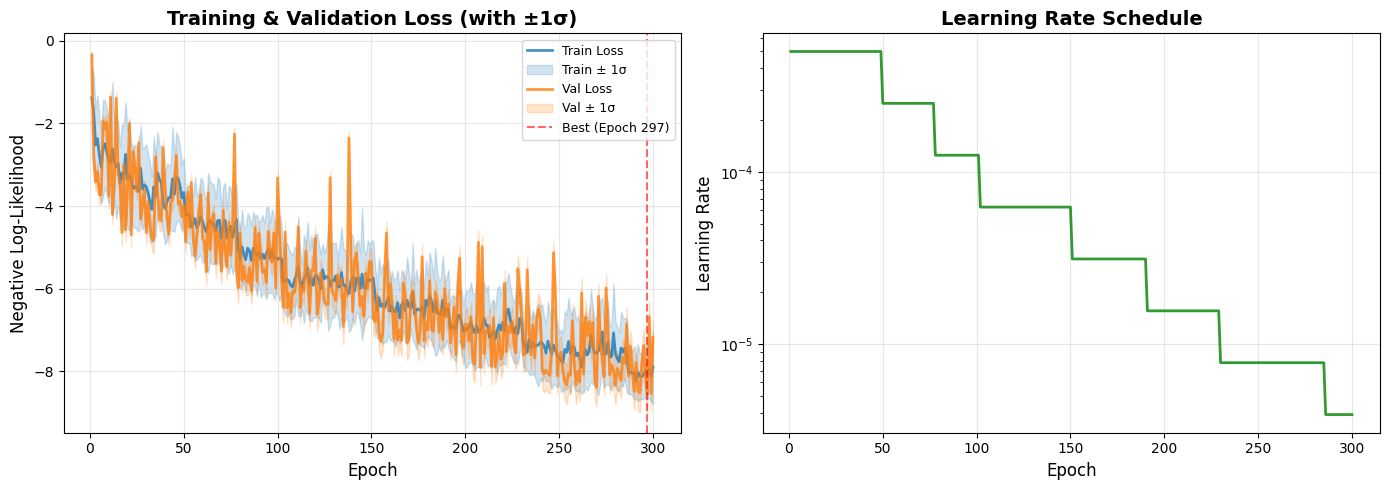

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = np.arange(1, len(train_losses) + 1)
train_losses_arr = np.array(train_losses)
train_stds_arr = np.array(std_train_losses)
val_losses_arr = np.array(val_losses)
val_stds_arr = np.array(std_val_losses)

# Plot 1: Train vs Validation Loss con bande di confidenza
ax1 = axes[0]

# Training loss con banda ± 1 std
ax1.plot(epochs_range, train_losses_arr, label='Train Loss', 
         linewidth=2, alpha=0.8, color='#1f77b4')
ax1.fill_between(epochs_range, 
                  train_losses_arr - train_stds_arr,
                  train_losses_arr + train_stds_arr,
                  alpha=0.2, color='#1f77b4', label='Train ± 1σ')

# Validation loss con banda ± 1 std
ax1.plot(epochs_range, val_losses_arr, label='Val Loss', 
         linewidth=2, alpha=0.8, color='#ff7f0e')
ax1.fill_between(epochs_range,
                  val_losses_arr - val_stds_arr,
                  val_losses_arr + val_stds_arr,
                  alpha=0.2, color='#ff7f0e', label='Val ± 1σ')

# Linea del miglior modello
ax1.axvline(x=checkpoint['epoch']+1, color='red', linestyle='--', 
            alpha=0.6, linewidth=1.5, label=f'Best (Epoch {checkpoint["epoch"]+1})')

ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Negative Log-Likelihood', fontsize=12)
ax1.set_title('Training & Validation Loss (with ±1σ)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(True, alpha=0.3)

# Plot 2: Learning Rate Schedule
ax2 = axes[1]
ax2.plot(epochs_range, learning_rates, linewidth=2, color='green', alpha=0.8)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Learning Rate', fontsize=12)
ax2.set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

La deviazione standard ti dice quanto è diversa la performance del modello tra un batch e l'altro all'interno della stessa epoca.

Bassa Std: Il modello sbaglia (o indovina) allo stesso modo su tutti i batch. È coerente.

Alta Std: Ci sono batch "facili" dove il modello va benissimo (loss molto bassa) e batch "difficili" o "strani" dove il modello va nel panico (loss altissima).

Dovrebbe diminuire nel tempo. Tuttavia, con dati di disastri naturali (che sono spesso "heavy-tailed", cioè con eventi rari ed estremi), la Std potrebbe rimanere un po' alta.

Se la Std rimane enorme (es. 10 o 20) mentre la Loss media non scende, significa che il modello non riesce a gestire gli outlier (i disastri estremi gli rompono le previsioni).

Come stabilizzare il training? (e quindi ridurre la standard deviation?):
- aumenta la batch size (gpu permettendo)
- gradient clipping (impedisce ad un singolo batch sfortunato, che quindi genera gradienti molto grandi, di distruggere i pesi del modello)

### Inference

In [34]:
def inverse_transform_predictions(y_scaled):
    """Convert from the normalized scale to normal dollars"""
    original_shape = y_scaled.shape
    y_log = target_scaler.inverse_transform(y_scaled.reshape(-1, 1))
    y_log = y_log.reshape(original_shape)
    return np.expm1(y_log)  # exp(log(1+x)) - 1 = x

In [ ]:
def predict_with_uncertainty(flow, context, n_samples=1000):
    # context shape: (Batch, Features)
    # if Batch size = 1 (un solo sample) accertati di aggiungere .unsqueeze(0) per avere la dimensione del batch)
    flow.eval()
    with torch.no_grad():
        samples = flow(context).sample((n_samples,)) # Shape: (n_samples, batch_size, output_feature(=1))
        samples_np = samples.squeeze(-1).cpu().numpy() # Shape: (n_samples, batch_size)

        samples_real = inverse_transform_predictions(samples_np)
        
        predictions = samples_real.mean(axis=0) # mean on the axis of the n_samples -> shape (batch_size,)
        uncertainties = samples_real.std(axis=0)
        
    return predictions, uncertainties

Inizio inferenza sul Test Set...
Inferenza completata su 18947 eventi.

RISULTATI DEL MODELLO (in scala reale)
MAE (Errore Medio Assoluto):  1,350,936.12 $
RMSE (Errore Quadratico Medio): 93,347,690.11 $
R2 Score: 0.0003


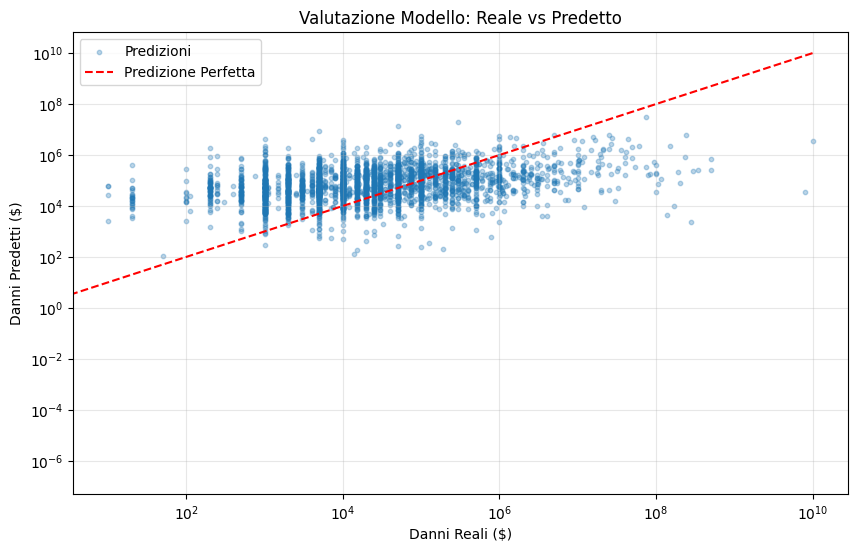


Esempi di predizione con incertezza:
Evento 0: Reale: 0 $ | Predetto: 17,764 $ ± 208,578
Evento 1: Reale: 0 $ | Predetto: 11,977 $ ± 118,178
Evento 2: Reale: 0 $ | Predetto: 69,859 $ ± 722,230
Evento 3: Reale: 50,000 $ | Predetto: 112,050 $ ± 961,075
Evento 4: Reale: 0 $ | Predetto: 189,421 $ ± 2,198,719


In [41]:
# Prediction on the test set

# Liste per salvare i risultati di tutti i batch
all_preds = []
all_uncertainties = []
all_targets = []

print("Inizio inferenza sul Test Set...")

# Iteriamo sui batch del test set per non saturare la memoria
for context_batch, damage_batch in test_loader:
    context_batch = context_batch.to(device)
    
    # 1. Predizione (La tua funzione restituisce già valori denormalizzati/reali)
    # Qui assumo restituisca numpy arrays.
    preds_real, unc_real = predict_with_uncertainty(flow, context_batch, n_samples=1000)
    
    # 2. Gestione del Target Reale (Ground Truth)
    # Dobbiamo denormalizzare anche i dati veri per poterli confrontare
    targets_real = inverse_transform_predictions(damage_batch.cpu().numpy())
    
    # 3. Accumulo risultati
    all_preds.append(preds_real)
    all_uncertainties.append(unc_real)
    all_targets.append(targets_real)

# Concateniamo tutti i batch in un unico array numpy
y_pred = np.concatenate(all_preds, axis=0)
y_std = np.concatenate(all_uncertainties, axis=0)
y_true = np.concatenate(all_targets, axis=0)

print(f"Inferenza completata su {len(y_pred)} eventi.")

# --- CALCOLO METRICHE ---
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("\n" + "="*30)
print("RISULTATI DEL MODELLO (in scala reale)")
print("="*30)
print(f"MAE (Errore Medio Assoluto):  {mae:,.2f} $")
print(f"RMSE (Errore Quadratico Medio): {rmse:,.2f} $")
print(f"R2 Score: {r2:.4f}")
print("="*30)

# --- GRAFICO: Predetto vs Reale ---
plt.figure(figsize=(10, 6))
# Facciamo un plot in scala logaritmica perché i danni variano di ordini di grandezza
plt.scatter(y_true, y_pred, alpha=0.3, s=10, label='Predizioni')

# Linea di perfezione (y = x)
p1 = max(y_true.max(), y_pred.max())
p2 = min(y_true.min(), y_pred.min())
plt.plot([p1, p2], [p1, p2], 'r--', label='Predizione Perfetta')

plt.xlabel('Danni Reali ($)')
plt.ylabel('Danni Predetti ($)')
plt.title('Valutazione Modello: Reale vs Predetto')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# --- ESEMPIO DI INCERTEZZA ---
# Mostriamo i primi 5 casi con la loro incertezza
print("\nEsempi di predizione con incertezza:")
for i in range(5):
    print(f"Evento {i}: Reale: {y_true[i][0]:,.0f} $ | Predetto: {y_pred[i]:,.0f} $ ± {y_std[i]:,.0f}")

In [40]:
print(f"\nDebug shapes:")
print(f"y_pred.shape:  {y_pred.shape}")
print(f"y_std.shape:   {y_std.shape}")
print(f"y_true.shape:  {y_true.shape}")
print(f"\nTipo di y_pred[0]: {type(y_pred[0])}") 


Debug shapes:
y_pred.shape:  (18947,)
y_std.shape:   (18947,)
y_true.shape:  (18947, 1)

Tipo di y_pred[0]: <class 'numpy.float32'>


In [37]:
# ESEMPI CON INCERTEZZA
# ==========================================
print("\n" + "="*50)
print("ESEMPI DI PREDIZIONE CON INCERTEZZA")
print("="*50)

for i in range(min(10, len(y_pred))):
    real = y_true[i]
    pred = y_pred[i]
    unc = y_std[i]
    err = abs(real - pred)
    err_pct = (err / real * 100) if real > 0 else 0
    
    print(f"\nEvento {i}:")
    print(f"  Reale:    {real:>12,.0f} $")
    print(f"  Predetto: {pred:>12,.0f} $ ± {unc:>8,.0f}")
    print(f"  Errore:   {err:>12,.0f} $ ({err_pct:>5.1f}%)")

print("\n" + "="*50)


ESEMPI DI PREDIZIONE CON INCERTEZZA

Evento 0:


TypeError: unsupported format string passed to numpy.ndarray.__format__

Inizio inferenza sul Test Set...
Inferenza completata su 18947 eventi.

RISULTATI DEL MODELLO (Scala Reale)
MAE (Errore Medio Assoluto):  1,352,994.62 $
RMSE (Errore Quadratico Medio): 93,357,794.60 $
R2 Score: 0.0001

TOP 5 CATASTROFI NEL TEST SET (Danni > 0)
Evento #9487:
  Reale:    10,000,108,544 $
  Predetto: 1,669,923 $ (± 13,483,388)
  Errore:   9,998,438,400 $
--------------------
Evento #9793:
  Reale:    8,000,063,488 $
  Predetto: 107,912 $ (± 1,641,800)
  Errore:   7,999,955,456 $
--------------------
Evento #9851:
  Reale:    500,000,128 $
  Predetto: 1,238,477 $ (± 22,404,100)
  Errore:   498,761,664 $
--------------------
Evento #15720:
  Reale:    500,000,128 $
  Predetto: 395,021 $ (± 2,374,215)
  Errore:   499,605,120 $
--------------------
Evento #14270:
  Reale:    340,000,896 $
  Predetto: 560,140 $ (± 8,932,528)
  Errore:   339,440,768 $
--------------------


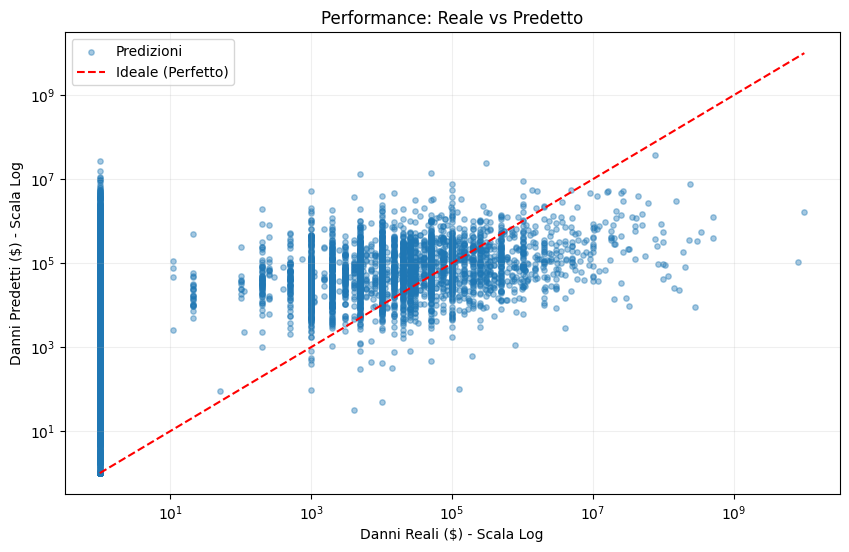

In [42]:
# ==========================================
# 1. INFERENZA SULL'INTERO TEST SET
# ==========================================
all_preds = []
all_uncertainties = []
all_targets = []

print("Inizio inferenza sul Test Set...")
flow.eval() # Fondamentale: mette il modello in modalità valutazione

# Iteriamo sui batch per efficienza
for context_batch, damage_batch in test_loader:
    context_batch = context_batch.to(device)
    
    # --- A. Predizione ---
    # Chiamiamo la tua funzione (che deve restituire numpy array)
    # Se la tua funzione restituisce tensor, aggiungi .cpu().numpy() qui sotto
    preds_real, unc_real = predict_with_uncertainty(flow, context_batch, n_samples=1000)
    
    # Se predict_with_uncertainty restituisce tensori, convertiamoli:
    if isinstance(preds_real, torch.Tensor):
        preds_real = preds_real.cpu().numpy()
    if isinstance(unc_real, torch.Tensor):
        unc_real = unc_real.cpu().numpy()

    # --- B. Ground Truth (Target Reale) ---
    # Denormalizziamo i dati veri per il confronto
    targets_real = inverse_transform_predictions(damage_batch.cpu().numpy())
    
    # --- C. Accumulo ---
    all_preds.append(preds_real)
    all_uncertainties.append(unc_real)
    all_targets.append(targets_real)

# Creiamo array unici giganti
y_pred = np.concatenate(all_preds, axis=0)
y_std = np.concatenate(all_uncertainties, axis=0)
y_true = np.concatenate(all_targets, axis=0)

print(f"Inferenza completata su {len(y_pred)} eventi.")

# ==========================================
# 2. CALCOLO METRICHE
# ==========================================
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("\n" + "="*40)
print("RISULTATI DEL MODELLO (Scala Reale)")
print("="*40)
print(f"MAE (Errore Medio Assoluto):  {mae:,.2f} $")
print(f"RMSE (Errore Quadratico Medio): {rmse:,.2f} $")
print(f"R2 Score: {r2:.4f}")

# ==========================================
# 3. VISUALIZZAZIONE ESEMPI CRITICI (>0)
# ==========================================
print("\n" + "="*40)
print("TOP 5 CATASTROFI NEL TEST SET (Danni > 0)")
print("="*40)

# Troviamo gli indici dove il danno reale è maggiore di zero
non_zero_indices = np.where(y_true > 100)[0] # Filtriamo > 100$ per evitare rumore minimo

if len(non_zero_indices) > 0:
    # Ordiniamo per trovare i danni maggiori (dal più grande al più piccolo)
    # y_true[non_zero_indices] prende solo i valori > 0
    # argsort li ordina, [::-1] inverte l'ordine (decrescente)
    sorted_indices = non_zero_indices[np.argsort(y_true[non_zero_indices].flatten())[::-1]]
    
    # Prendiamo i primi 5 (o meno se ce ne sono pochi)
    top_k = min(5, len(sorted_indices))
    
    for i in range(top_k):
        idx = sorted_indices[i]
        real_val = y_true[idx][0]
        pred_val = y_pred[idx]
        unc_val = y_std[idx]
        
        # Calcoliamo l'errore percentuale per questo singolo evento
        err_perc = abs(real_val - pred_val) / real_val * 100
        
        print(f"Evento #{idx}:")
        print(f"  Reale:    {real_val:,.0f} $")
        print(f"  Predetto: {pred_val:,.0f} $ (± {unc_val:,.0f})")
        print(f"  Errore:   {real_val - pred_val:,.0f} $")
        print("-" * 20)
else:
    print("Nessun evento con danni significativi (>100$) trovato nel test set.")

# ==========================================
# 4. PLOT (Scala Logaritmica)
# ==========================================
plt.figure(figsize=(10, 6))

# Aggiungiamo una piccola costante (epsilon) per evitare log(0)
epsilon = 1.0 
plt.scatter(y_true + epsilon, y_pred + epsilon, alpha=0.4, s=15, label='Predizioni')

# Linea ideale
p_min = min((y_true+epsilon).min(), (y_pred+epsilon).min())
p_max = max((y_true+epsilon).max(), (y_pred+epsilon).max())
plt.plot([p_min, p_max], [p_min, p_max], 'r--', label='Ideale (Perfetto)')

plt.xlabel('Danni Reali ($) - Scala Log')
plt.ylabel('Danni Predetti ($) - Scala Log')
plt.title('Performance: Reale vs Predetto')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()